In [50]:
from spin_lattices import KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from boolean_analysis import BooleanFourierAnalyser, keep_largest_n, ScorerType, get_scorer
from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import lzma

%matplotlib widget

## How properties of Fourier spectra changes with the lattice size
1. How many elements of Fourier spectra are needed to achieve 95% overlap?
2. How fast the absolute value of Fourier coefficients decline comparing with the coefficients of the ground state in the ordinary basis.
3. What happens if we keep elements of small degrees?
3. Which probability distribution is better to use?

In [51]:
J2 = 0.9
system = HeisenbergJ1J2(
    KagomeLattice(width=2, height=2),
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=Path("groundstates"),
)
analyzer = BooleanFourierAnalyser(
    system=system,
    use_subset_symmetries=True,
)


number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.9-True-1-1.pickle
Ground state energy is -20.6362854929


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


In [52]:
def how_many_terms_to_achieve_score(
    analyzer: BooleanFourierAnalyser,
    scorer: str | ScorerType = "overlap",
    target_score: float = 0.95,
    min_terms: int = 1,
    max_terms: int = 101,
    step: int = 10,
    show_progress: bool = True,
) -> int | None:
    """
    How many terms are needed to reconstruct the sign structure of the ground state
    with the given score?

    Parameters
    ----------
    analyzer : BooleanFourierAnalyser
        The analyzer to use.

    scorer : str | ScorerType, optional

    target_score : float, optional
        The target score, by default 0.95

    min_terms : int, optional
        The minimum number of terms to try, by default 1

    max_terms : int, optional
        The maximum number of terms to try, by default 101

    step : int, optional
        The step size, by default 10

    Returns
    -------
    int | None
        The number of terms needed to achieve the target score, or None if the target
        score could not be achieved.
    """

    evaluation_set = analyzer.system.basis.states
    prediction = np.zeros_like(evaluation_set, dtype="float64")
    state_info_df = batched_state_info_df(
        analyzer.system.basis, analyzer.system.canonical_basis.states
    )

    for n_terms in range(min_terms, max_terms, step):
        if n_terms == min_terms:
            analyzer.set_truncate_strategy(keep_largest_n(n_terms))
        else:
            analyzer.set_truncate_strategy(keep_largest_n(step, offset=max(0, n_terms - step)))

        prediction += analyzer.predict(evaluation_set)

        true = analyzer._get_signal_df(analyzer.system.canonical_basis.states)
        prediction_expanded = np.asarray(
            state_info_df.merge(
                pd.Series(prediction, name="prediction", index=evaluation_set),
                left_on="representative",
                right_index=True,
                how="left",
            )["prediction"].values
        )
        score = get_scorer(scorer)(true, np.sign(prediction_expanded))
        if show_progress:
            print(f"{n_terms} terms: {score:.3f}")
        if score >= target_score:
            return n_terms
    return None


In [53]:
# Marshall

analyzer = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        KagomeLattice(width=2, height=3),
        J1=1,
        J2=0,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=Path("groundstates"),
    ),
    use_subset_symmetries=True,
)
analyzer.fit(analyzer.system.canonical_basis.states)

assert how_many_terms_to_achieve_score(analyzer, scorer="accuracy", target_score=0.99) == 1
assert how_many_terms_to_achieve_score(analyzer, scorer="overlap", target_score=0.99) == 1
assert how_many_terms_to_achieve_score(analyzer, scorer="accuracy", target_score=1.01) is None

# Frustrated

analyzer = BooleanFourierAnalyser(
    system=HeisenbergJ1J2(
        KagomeLattice(width=2, height=3),
        J1=1,
        J2=0.8,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=Path("groundstates"),
    ),
    use_subset_symmetries=True,
)
analyzer.fit(analyzer.system.canonical_basis.states)


def assert_is_large(terms: int | None):
    if terms is not None:
        assert terms > 1


assert_is_large(how_many_terms_to_achieve_score(analyzer, scorer="accuracy", target_score=0.99))
assert_is_large(how_many_terms_to_achieve_score(analyzer, scorer="overlap", target_score=0.99))


number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


KeyboardInterrupt: 

In [ ]:
results = []
for J2 in tqdm([0.5, 0.6, 0.7, 0.8, 0.9, 1]):
    analyzer = BooleanFourierAnalyser(
        system=HeisenbergJ1J2(
            KagomeLattice(width=2, height=4),
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=Path("groundstates"),
        ),
        use_subset_symmetries=True,
        show_progress=True,
    )
    terms = how_many_terms_to_achieve_score(
        analyzer,
        scorer="overlap",
        target_score=0.95,
        step=10,
        max_terms=1001,
        show_progress=True,
    )
    results.append(dict(J2=J2, terms=terms))
results_df = pd.DataFrame(results)
sns.relplot(data=results_df, x="J2", y="terms", kind="line")


  0%|          | 0/6 [00:00<?, ?it/s][Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.5-True-1-1.pickle
Ground state energy is -39.4742602743


Batch 1/10


...

141 terms: 0.286


151 terms: 0.310


161 terms: 0.313


 17%|█▋        | 1/6 [05:11<25:58, 311.68s/it]


KeyboardInterrupt: 

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763
1 terms: 0.076
11 terms: 0.739
21 terms: 0.782
31 terms: 0.794
41 terms: 0.807
51 terms: 0.818
61 terms: 0.814
71 terms: 0.823
81 terms: 0.834
91 terms: 0.833
101 terms: 0.841
111 terms: 0.842
121 terms: 0.857
131 terms: 0.863
141 terms: 0.869
151 terms: 0.873
161 terms: 0.883
171 terms: 0.891
181 terms: 0.898
191 terms: 0.905
201 terms: 0.910
211 terms: 0.914
221 terms: 0.918
231 terms: 0.922
241 terms: 0.924
251 terms: 0.928
261 terms: 0.932
271 terms: 0.939
281 terms: 0.940
291 terms: 0.944
301 terms: 0.945
311 terms: 0.948
321 terms: 0.951


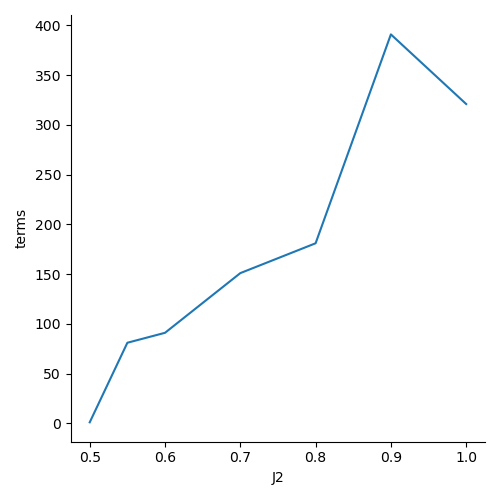

In [ ]:
experiment_dir = Path("experiments/kagome24-2023-01-18")

J2s = sorted(
    [
        float(parse.search("learner-J2={}.pickle.lz", str(file)).fixed[0])
        for file in experiment_dir.glob("learner-J2=*.pickle.lz")
    ]
)
results = []

for J2 in J2s:
    analyzer = BooleanFourierAnalyser(
        system=HeisenbergJ1J2(
            KagomeLattice(width=2, height=4),
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=Path("groundstates"),
        ),
        use_subset_symmetries=True,
        show_progress=True,
    )
    analyzer.restore_learner_from_pickle(experiment_dir / f"learner-J2={J2!r}.pickle.lz")
    terms = how_many_terms_to_achieve_score(
        analyzer, scorer="overlap", target_score=0.95, step=10, max_terms=1001, show_progress=True
    )

    results.append(dict(J2=J2, terms=terms))
results_df = pd.DataFrame(results)
sns.relplot(data=results_df, x="J2", y="terms", kind="line")


In [ ]:
results_small = []
for height in [2, 3]:
    for J2 in J2s:
        analyzer = BooleanFourierAnalyser(
            system=HeisenbergJ1J2(
                KagomeLattice(width=2, height=height),
                J1=1,
                J2=J2,
                use_symmetries=True,
                spin_inversion=1,
                ground_state_cache_dir=Path("groundstates"),
            ),
            use_subset_symmetries=True,
            show_progress=True,
        )
        analyzer.fit(analyzer.system.canonical_basis.states)
        terms = how_many_terms_to_achieve_score(
            analyzer,
            scorer="overlap",
            target_score=0.95,
            step=1,
            max_terms=1001,
            show_progress=True,
        )
        results_small.append(
            dict(J2=J2, terms=terms, height=height, number_spins=analyzer.system.number_spins)
        )

results_df_small = pd.DataFrame(results_small)


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.5-True-1-1.pickle
Ground state energy is -19.9412664298


100%|██████████| 10/10 [00:00<00:00, 143.70it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


1 terms: 1.000
number_spins=12
Symmetry group contains 16 elements
Hilbert space dimension is 47
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x2-1.0-0.55-True-1-1.pickle
Ground state energy is -19.6232963276


100%|██████████| 10/10 [00:00<00:00, 60.67it/s]
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


...

Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-0.9-True-1-1.pickle
Ground state energy is -30.0803071877


100%|██████████| 487/487 [00:08<00:00, 57.30it/s]


1 terms: 0.475
2 terms: 0.525
3 terms: 0.632
4 terms: 0.627
5 terms: 0.725
6 terms: 0.762
7 terms: 0.757
8 terms: 0.736
9 terms: 0.694
10 terms: 0.788
11 terms: 0.786
12 terms: 0.785
13 terms: 0.820
14 terms: 0.823
15 terms: 0.826
16 terms: 0.870
17 terms: 0.869
18 terms: 0.870
19 terms: 0.872
20 terms: 0.876
21 terms: 0.902
22 terms: 0.907
23 terms: 0.908
24 terms: 0.923
25 terms: 0.925
26 terms: 0.926
27 terms: 0.918
28 terms: 0.915
29 terms: 0.919
30 terms: 0.930
31 terms: 0.933
32 terms: 0.939
33 terms: 0.940
34 terms: 0.944
35 terms: 0.939
36 terms: 0.958
number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102
Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-True-1-1.pickle
Ground state energy is -31.0548143836


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
100%|██████████| 487/487 [00:09<00:00, 51.38it/s]


1 terms: 0.427
2 terms: 0.485
3 terms: 0.561
4 terms: 0.601
5 terms: 0.528
6 terms: 0.675
7 terms: 0.688
8 terms: 0.676
9 terms: 0.775
10 terms: 0.759
11 terms: 0.762
12 terms: 0.795
13 terms: 0.808
14 terms: 0.827
15 terms: 0.844
16 terms: 0.830
17 terms: 0.828
18 terms: 0.872
19 terms: 0.869
20 terms: 0.867
21 terms: 0.872
22 terms: 0.880
23 terms: 0.898
24 terms: 0.899
25 terms: 0.936
26 terms: 0.932
27 terms: 0.931
28 terms: 0.942
29 terms: 0.946
30 terms: 0.946
31 terms: 0.944
32 terms: 0.951


In [ ]:
results_full = pd.concat(
    [
        results_df.assign(height=4, number_spins=len(KagomeLattice(width=2, height=4).sites)),
        results_df_small,
    ]
)


In [ ]:
%matplotlib inline

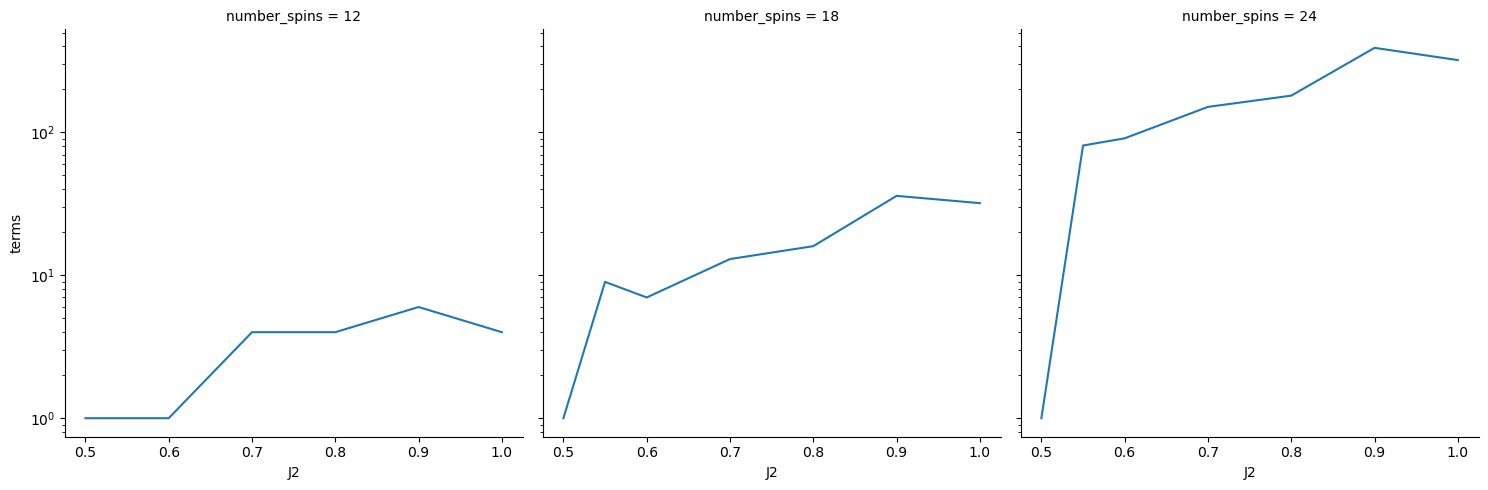

In [ ]:
g = sns.relplot(data=results_full, x="J2", y="terms", col="number_spins", kind="line")
# make y axis log scale
g.set(yscale="log")


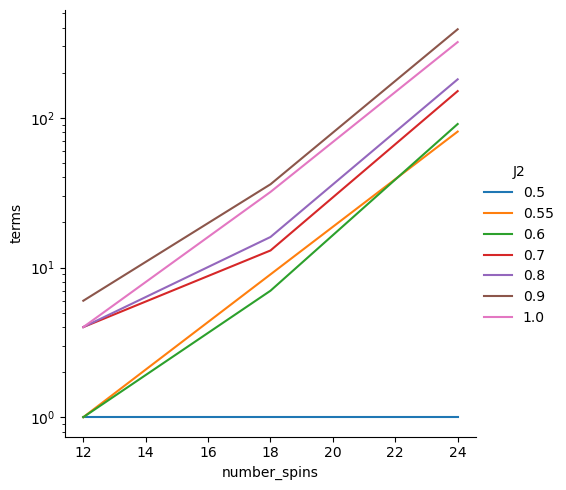

In [91]:
sns.relplot(
    data=results_full.assign(J2=lambda x: x["J2"].astype("str")),
    x="number_spins",
    y="terms",
    hue="J2",
    kind="line",
    markers=True,
).set(yscale="log")


In [ ]:
def get_analyzer_from_pickle(J2):
    analyzer = BooleanFourierAnalyser(
        system=HeisenbergJ1J2(
            KagomeLattice(width=2, height=4),
            J1=1,
            J2=J2,
            use_symmetries=True,
            spin_inversion=1,
            ground_state_cache_dir=Path("groundstates"),
        ),
        use_subset_symmetries=True,
        show_progress=True,
    )
    analyzer.restore_learner_from_pickle(experiment_dir / f"learner-J2={J2!r}.pickle.lz")
    return analyzer


In [70]:
get_analyzer_from_pickle(0.9).fourier_basis_state_info_df

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.9-True-1-1.pickle
Ground state energy is -41.5204728634


,representative,character
state,,
0,0,1
1,1,1
2,2,1
3,3,1
4,1,1
...,...,...
16777211,1,1
16777212,3,1
16777213,2,1


In [71]:
analyzer = get_analyzer_from_pickle(0.9)


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.9-True-1-1.pickle
Ground state energy is -41.5204728634


In [73]:
analyzer.fourier_basis_state_info_df['representative'].nunique()

528656

In [ ]:
analyzer.fourier_basis_state_info_df


,representative,character
state,,
0,0,1
1,1,1
2,2,1
3,3,1
4,1,1
...,...,...
262139,1,-1
262140,3,-1
262141,2,-1


In [56]:
J2_to_analyzer = {J2: get_analyzer_from_pickle(J2) for J2 in J2s}

number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.5-True-1-1.pickle
Ground state energy is -39.4742602743
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.55-True-1-1.pickle
Ground state energy is -39.2486441956
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


...

Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.8-True-1-1.pickle
Ground state energy is -40.5183420067
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.9-True-1-1.pickle
Ground state energy is -41.5204728634
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...


Finding system ground state
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
Ground state energy is -42.8245991763


In [110]:
mean_abs_coeffs = {
    J2: analyzer.learner.coeffs_ser_.to_frame().assign(
    hamming_weight=lambda x: popcount(x.index),
    abs_coeff=lambda x: x["coeff"].abs(),
).reset_index().rename(columns={"index": "state"}).assign(
    state=lambda x: np.where(
        x["hamming_weight"] > analyzer.system.number_spins // 2,
        x["state"] ^ (2**analyzer.system.number_spins - 1),
        x["state"],
    )
).assign(
    hamming_weight=lambda x: popcount(x["state"])
).set_index(
    "state"
).groupby(
    "hamming_weight"
)[
    "abs_coeff"
].mean()
    for J2, analyzer in J2_to_analyzer.items()
}


In [75]:
%matplotlib inline

<AxesSubplot: xlabel='hamming_weight'>

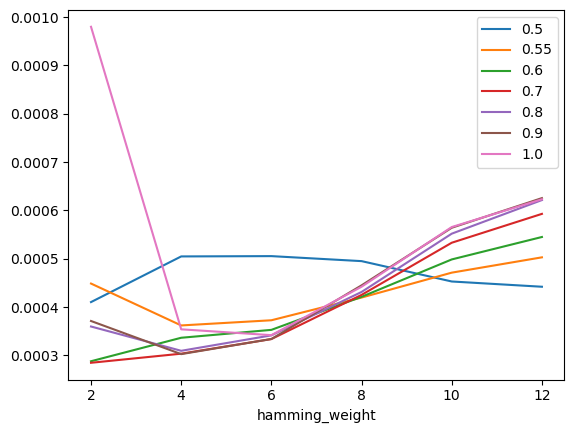

In [117]:
pd.DataFrame(mean_abs_coeffs)[lambda x: x.index % 2 == 0].drop([0]).plot()

In [ ]:
def keep_small_degree(n: int):
    def truncate(s: pd.Series) -> pd.Series:
        return s.to_frame().assign(degree=popcount(s.index))[lambda x: x['degree'] < n]['coeff']

def keep_large_degree(n: int):
    def truncate(s: pd.Series) -> pd.Series:
        return s.to_frame().assign(degree=popcount(s.index))[lambda x: x['degree'] > n]['coeff']

[dict(J2=J2, degree=degree, score=analyzer.set_truncate_strategy(keep_small_degree(degree)).prediction_score(analyzer.system.basis.states, scorer='overlap'))  for J2, analyzer in tqdm(J2_to_analyzer.items()) for degree in [2, 3, 4]]
    
    